In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import recall_score
from sklearn.base import BaseEstimator, ClassifierMixin

In [2]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [3]:
pd.set_option("display.max_rows", None)   # mostra todas as linhas
pd.set_option("display.max_columns", None) # mostra todas as colunas
pd.set_option("display.width", None)      # evita quebra de linha

# Carregamento dos dados

In [4]:
df = pd.read_pickle('dataset_binarios_solgel_solstate_18-09-26.pkl')

In [5]:
df_solgel = df[df['synthesis_type']=='sol-gel']
df_solstate = df[df['synthesis_type']=='solid-state']

# Separação dos dados

In [6]:
features_selecionadas = [
    'period_1',
    'atomic_number_1',
    'atomic_radius_1',
    'vdw_radius_1',
    'nvalence_1',  
    'dipole_polarizability_1',
    'electronegativity_pauling_1', 
    'zeff_1',
    'period_2',
    'atomic_number_2',
    'atomic_radius_2',
    'vdw_radius_2',
    'nvalence_2', 
    'dipole_polarizability_2',
    'electronegativity_pauling_2',
    'zeff_2',
    'nelement_1', 'nelement_2',
    'id'
]

In [7]:
x_solgel1 = df_solgel[features_selecionadas]
x_solstate1 = df_solstate[features_selecionadas]

C:\Users\HF\AppData\Local\Temp\ipykernel_16580\1338271604.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


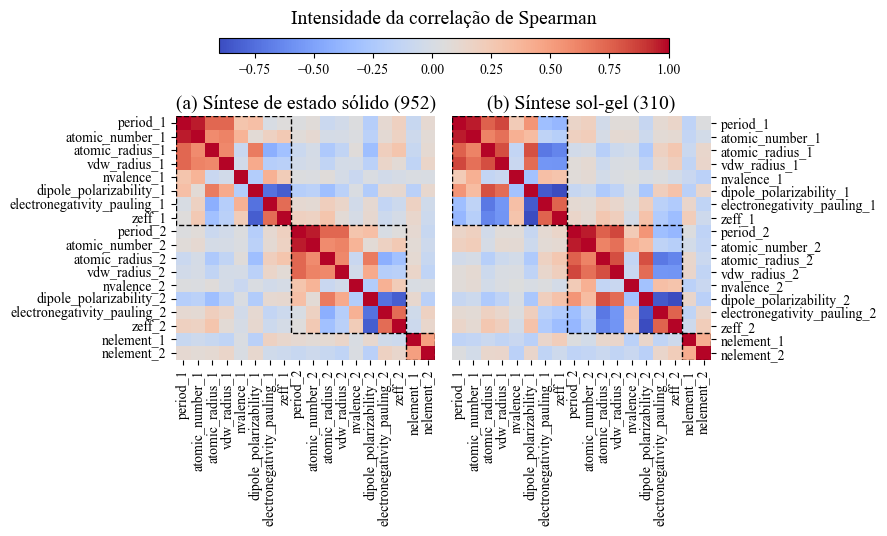

In [8]:
cor = "coolwarm"

# Calcula as matrizes de correlação
corr_state = x_solstate1.drop(columns=['id']).corr(method='spearman')
corr_gel = x_solgel1.drop(columns=['id']).corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

vmin = min(corr_state.min().min(), corr_gel.min().min())
vmax = max(corr_state.max().max(), corr_gel.max().max())

hm1 = sns.heatmap(corr_state, cmap=cor, ax=axes[0], vmin=vmin, vmax=vmax, cbar=False)
axes[0].set_title(f"(a) Síntese de estado sólido ({len(x_solstate1)})", fontsize=14)
axes[0].tick_params(left=True, labelleft=True)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)  # horizontal

hm2 = sns.heatmap(corr_gel, cmap=cor, ax=axes[1], vmin=vmin, vmax=vmax, cbar=False)
axes[1].set_title(f"(b) Síntese sol-gel ({len(x_solgel1)})", fontsize=14)
axes[1].tick_params(right=True, labelright=True, left=False, labelleft=False)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)  # horizontal

# Regiões no heatmap
axes[0].add_patch(patches.Rectangle((0,0), 8, 8, fill=False, edgecolor="black", linestyle="--", linewidth=1))
axes[0].add_patch(patches.Rectangle((8,8), 8, 8, fill=False, edgecolor="black", linestyle="--", linewidth=1))
axes[0].add_patch(patches.Rectangle((16,16), 2, 2, fill=False, edgecolor="black", linestyle="--", linewidth=1))
axes[1].add_patch(patches.Rectangle((0,0), 8, 8, fill=False, edgecolor="black", linestyle="--", linewidth=1))
axes[1].add_patch(patches.Rectangle((8,8), 8, 8, fill=False, edgecolor="black", linestyle="--", linewidth=1))
axes[1].add_patch(patches.Rectangle((16,16), 2, 2, fill=False, edgecolor="black", linestyle="--", linewidth=1))

# Barra horizontal única no topo
cbar_ax = fig.add_axes([0.25, 0.98, 0.5, 0.03])
cbar = fig.colorbar(hm1.collections[0], cbar_ax, orientation="horizontal")
cbar.ax.set_title("Intensidade da correlação de Spearman", fontsize=14, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("correlation.png", dpi=600, bbox_inches="tight")
#plt.show()

# Treinamento e Avaliação dos Modelos de Aprendizado de Máquina

In [9]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- 1. Define the PyTorch Autoencoder Wrapper for Scikit-Learn ---
class AutoencoderOCC(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, contamination=0.05, epochs=50, lr=0.01, batch_size=16):
        self.input_dim = input_dim
        self.contamination = contamination
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size

    def _build_model(self, input_dim):
        bottleneck = max(2, input_dim // 2)
        return nn.Sequential(
            nn.Linear(input_dim, bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, input_dim) 
        )

    def fit(self, X, y=None):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        input_dim = X_tensor.shape[1]
        
        self.model_ = self._build_model(input_dim)
        
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        # Training Loop
        self.model_.train()
        dataset = torch.utils.data.TensorDataset(X_tensor, X_tensor)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        for epoch in range(self.epochs):
            for batch_x, _ in loader:
                optimizer.zero_grad()
                outputs = self.model_(batch_x)
                loss = criterion(outputs, batch_x)
                loss.backward()
                optimizer.step()
        
        # Calculate Reconstruction Errors on training data to set the threshold
        self.model_.eval()
        with torch.no_grad():
            train_preds = self.model_(X_tensor)
            errors = torch.mean((X_tensor - train_preds) ** 2, dim=1).numpy()
            
        self.threshold_ = np.quantile(errors, 1.0 - self.contamination)
        return self

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.model_.eval()
        with torch.no_grad():
            preds = self.model_(X_tensor)
            errors = torch.mean((X_tensor - preds) ** 2, dim=1).numpy()
        
        # 1 = Inlier (Error below threshold), -1 = Outlier (Error above threshold)
        return np.where(errors <= self.threshold_, 1, -1)

In [10]:
def get_pipelines():
    return {
        "OneClassSVM": make_pipeline(
            StandardScaler(),
            OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
        ),
        "Isolation Forest": make_pipeline(
            StandardScaler(),
            IsolationForest(contamination='auto', random_state=42)
        ),
        "Local Outlier Factor": make_pipeline(
            StandardScaler(),
            LocalOutlierFactor(n_neighbors=20, contamination='auto', novelty=True)
        ),
        "Autoencoder": make_pipeline(
            StandardScaler(),
            AutoencoderOCC(contamination=0.0, epochs=60, lr=0.005, batch_size=32)
        )
    }

In [11]:
def evaluate_occ_models_cv5(X, dataset_name):

    resultados = [] 
    ids = X["id"].values # Extrai os grupos (ids) ANTES de remover
    
    # Remove a coluna 'id' e mantém apenas as numéricas
    X_num = X.drop(columns=["id"]).select_dtypes(include=[np.number])
    X_arr = X_num.values
    
    gkf = GroupKFold(n_splits=5)

    print(f"\n=== Resultados de Recall (5-Fold CV) - Dataset: {dataset_name} ===")
    
    models = get_pipelines()
    
    for model_name, pipeline in models.items():
        recall_scores = []
        
        for train_idx, test_idx in gkf.split(X_arr, groups=ids):
            X_train, X_test = X_arr[train_idx], X_arr[test_idx]
            
            pipeline.fit(X_train)
            preds = pipeline.predict(X_test)
            
            y_true = np.ones(len(X_test))
            fold_recall = recall_score(y_true, preds, pos_label=1, zero_division=0)
            recall_scores.append(fold_recall)
            
        mean_recall = np.mean(recall_scores)
        std_recall = np.std(recall_scores)
        sem_recall = np.std(recall_scores)/len(recall_scores)**0.5
        ob={
            'model':model_name,
            'mean_recall':mean_recall,
            'std_recall':std_recall,
            'sem_recall':sem_recall
        }
        resultados.append(ob)
        
        print(f"{model_name:<22} -> Mean Recall: {mean_recall:.4f} (±{sem_recall:.4f})")
    return(resultados)

In [12]:
print("--- 5-Fold OCC Recall Validation Results ---")
solgel_results = evaluate_occ_models_cv5(x_solgel1, "Solgel")
solstate_results = evaluate_occ_models_cv5(x_solstate1, "Solstate")

--- 5-Fold OCC Recall Validation Results ---

=== Resultados de Recall (5-Fold CV) - Dataset: Solgel ===
OneClassSVM            -> Mean Recall: 0.8645 (±0.0294)
Isolation Forest       -> Mean Recall: 0.8806 (±0.0272)
Local Outlier Factor   -> Mean Recall: 0.9419 (±0.0108)
Autoencoder            -> Mean Recall: 0.9935 (±0.0058)

=== Resultados de Recall (5-Fold CV) - Dataset: Solstate ===
OneClassSVM            -> Mean Recall: 0.9118 (±0.0178)
Isolation Forest       -> Mean Recall: 0.8615 (±0.0150)
Local Outlier Factor   -> Mean Recall: 0.8318 (±0.0141)
Autoencoder            -> Mean Recall: 0.9989 (±0.0009)


In [13]:
df_solstate_results = pd.DataFrame(solstate_results)
df_solgel_results = pd.DataFrame(solgel_results)

df_solstate_results.to_pickle('resultados_solstate.pkl')
df_solgel_results.to_pickle('resultados_solgel.pkl')